In [17]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [18]:
shp_path = "data/calenviroscreen40_shp/CES4 Final Shapefile.shp"
shape = gpd.read_file(shp_path)
shape = shape.replace([-999, -998], np.nan)

In [19]:
pctl_cols = [
    'CIscoreP','OzoneP','PM2_5_P','DieselPM_P','PesticideP','Tox_Rel_P',
    'TrafficP','DrinkWatP','Lead_P','CleanUpP','GWThreatP','HazWasteP',
    'ImpWatBdP','SolWasteP','PolBurdP','AsthmaP','LowBirWP','CardiovasP',
    'EducatP','Ling_IsolP','PovertyP','UnemplP','HousBurdP','PopCharP'
]
race_cols = ['Hispanic','White','AfricanAm','NativeAm','OtherMult','AAPI']

for c in (pctl_cols + race_cols):
    if c in shape.columns:
        shape[c] = pd.to_numeric(shape[c], errors="coerce")

shape = shape.to_crs(epsg=3857)

In [20]:
def qmap(shape, col, title=None, cmap="viridis", k=6, figsize=(10,10), save=None):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_axis_off()
    shape.plot(
        column=col,
        scheme="quantiles",
        k=k,
        cmap=cmap,
        legend=True,
        ax=ax,
        edgecolor="white",
        linewidth=0.08,
        missing_kwds={"color": "lightgrey", "label": "Missing"},
        legend_kwds={"loc": "lower left"}
    )
    ax.set_title(title if title else col, fontsize=14)
    plt.show()

In [21]:
burden = "PolBurdP"
# burden = "CIscoreP"

In [22]:
exposure_vars = ["OzoneP", "PM2_5_P", "DieselPM_P", "TrafficP", "Tox_Rel_P", "PesticideP"]
shape["ExposureIdx"] = shape[exposure_vars].mean(axis=1, skipna=True)
# burden = "ExposureIdx"

--- Hispanic ---


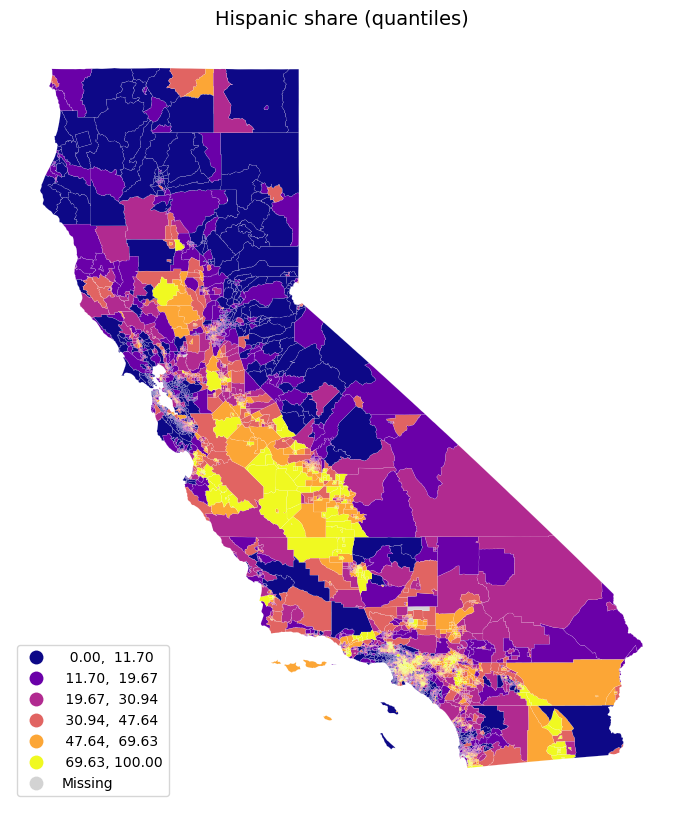

--- White ---


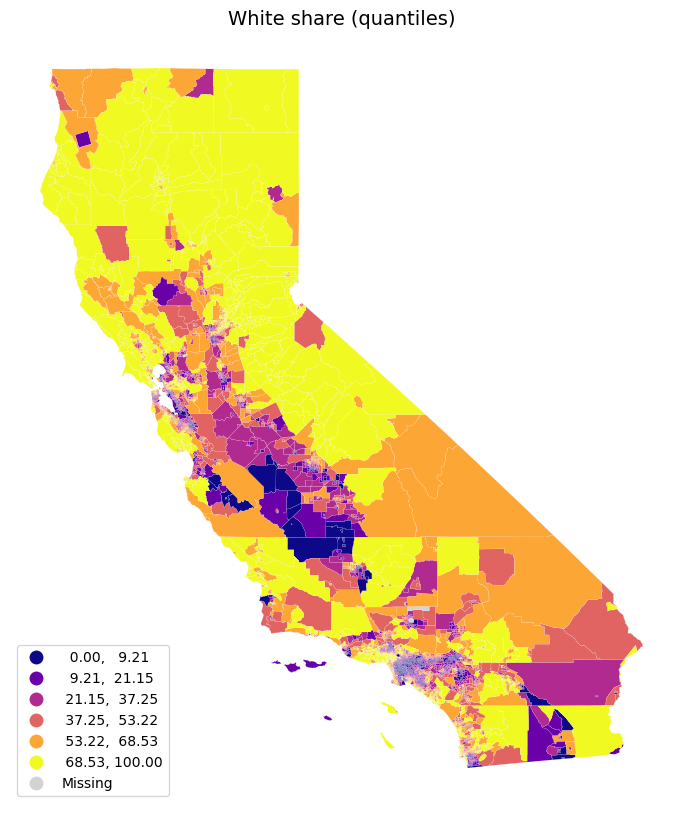

--- AfricanAm ---


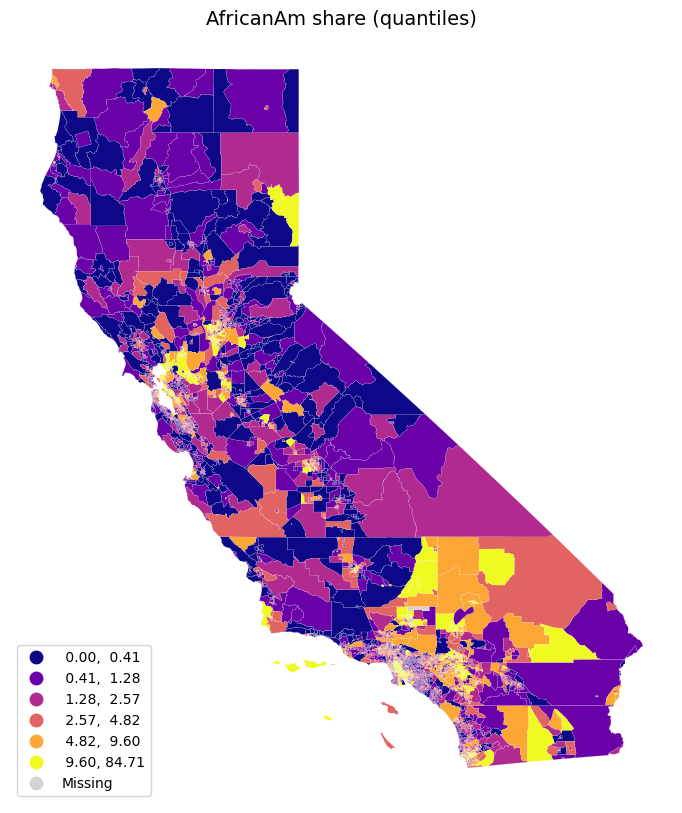

--- NativeAm ---


/srv/conda/envs/notebook/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


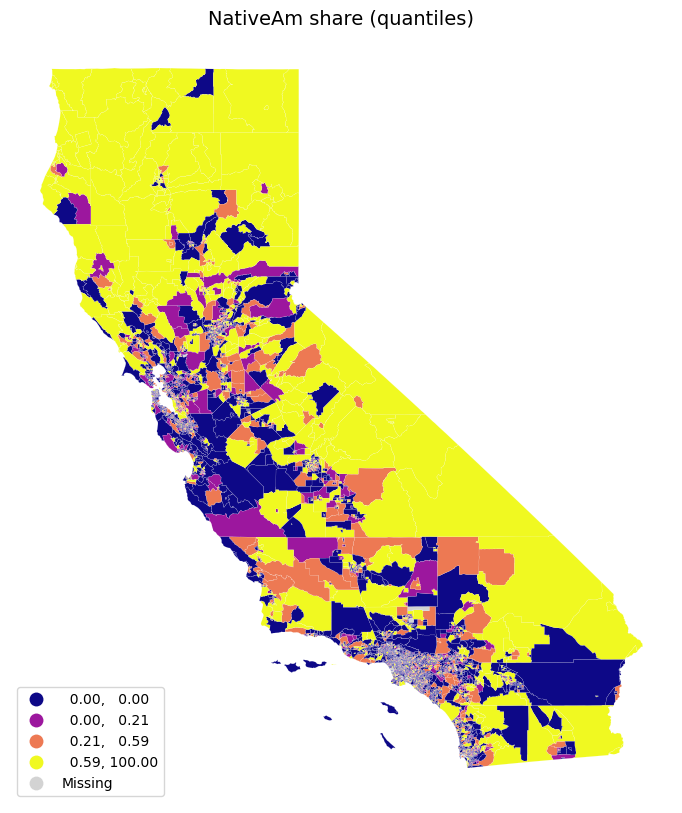

--- OtherMult ---


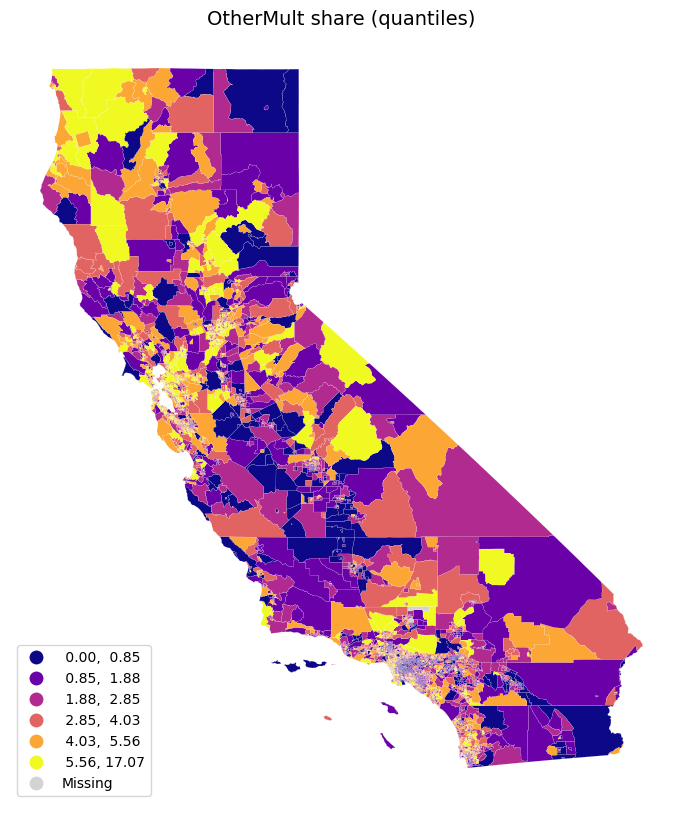

--- AAPI ---


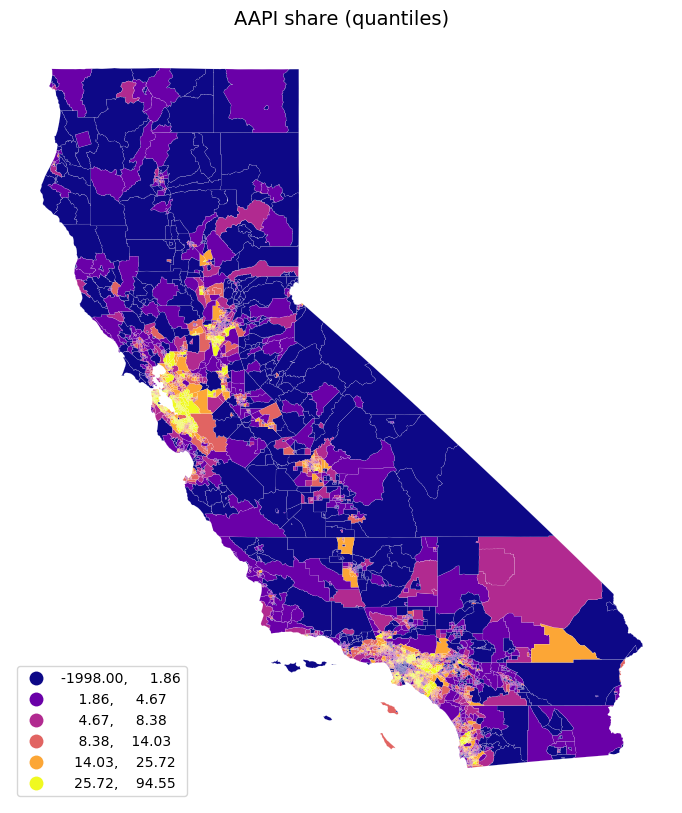

In [25]:
for race in race_cols:
    print(f"--- {race} ---")

    # 1: Map depicting race share (for each race)
    qmap(
        shape,
        race,
        title=f"{race} share (quantiles)",
        cmap="plasma"
    )
